In [2]:
import pandas as pd

# Load dataset
# Try to load the dataset
try:
    df = pd.read_csv("students.csv")
except FileNotFoundError:
    # If the file is not found, create a dummy DataFrame for demonstration purposes
    print("students.csv not found. Creating a dummy DataFrame for demonstration.")
    data = {
        'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
        'math': [85, 60, 92, 78, 45, 70],
        'science': [70, 80, 88, 65, 55, 75],
        'english': [90, 75, 80, 85, 60, 68],
        'history': [65, 70, 75, 90, 50, 82],
        'pe': [95, 88, 70, 75, 65, 90],
        'passed': [1, 0, 1, 1, 0, 1] # 1 for pass, 0 for fail
    }
    df = pd.DataFrame(data)

# 1. First 5 rows
print("First 5 rows:")
print(df.head())

# 2. Shape and Data Types
print("\nShape of dataset (rows, columns):")
print(df.shape)

print("\nData types of each column:")
print(df.dtypes)

# 3. Summary Statistics
print("\nSummary statistics:")
print(df.describe())

# 4. Count of Pass and Fail students
print("\nPass/Fail count:")
print(df['passed'].value_counts())

# 5. Average score per subject for Pass vs Fail
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores for PASSING students:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage scores for FAILING students:")
print(df[df['passed'] == 0][subject_cols].mean())

# 6. Student with highest overall average
df["avg_score"] = df[subject_cols].mean(axis=1)

top_student = df.loc[df["avg_score"].idxmax()]

print("\nStudent with highest average score:")
print(top_student[['name', 'avg_score']])

students.csv not found. Creating a dummy DataFrame for demonstration.
First 5 rows:
      name  math  science  english  history  pe  passed
0    Alice    85       70       90       65  95       1
1      Bob    60       80       75       70  88       0
2  Charlie    92       88       80       75  70       1
3    David    78       65       85       90  75       1
4      Eve    45       55       60       50  65       0

Shape of dataset (rows, columns):
(6, 7)

Data types of each column:
name       object
math        int64
science     int64
english     int64
history     int64
pe          int64
passed      int64
dtype: object

Summary statistics:
            math    science    english    history         pe    passed
count   6.000000   6.000000   6.000000   6.000000   6.000000  6.000000
mean   71.666667  72.166667  76.333333  72.000000  80.500000  0.666667
std    17.212399  11.583034  11.075498  13.928388  12.144958  0.516398
min    45.000000  55.000000  60.000000  50.000000  65.000000  0.0

students.csv not found. Creating a dummy DataFrame for demonstration.


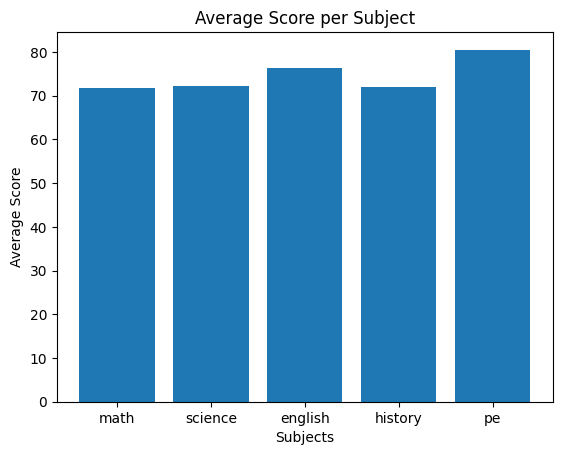

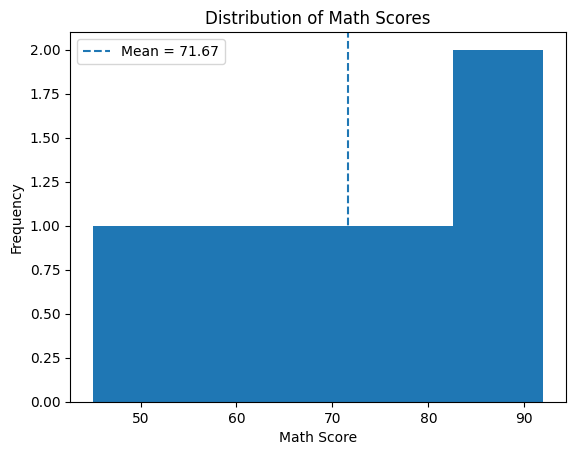

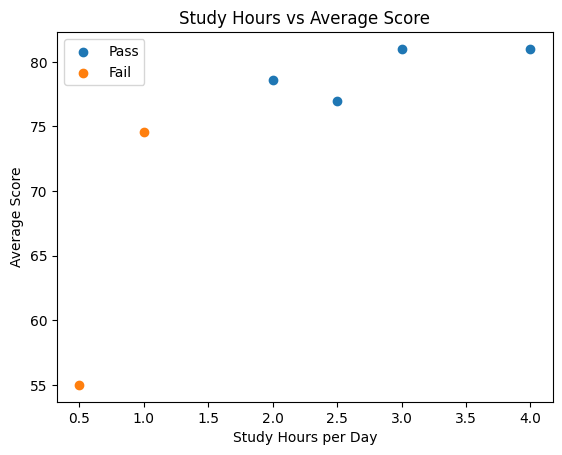

/tmp/ipykernel_2235/569272705.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


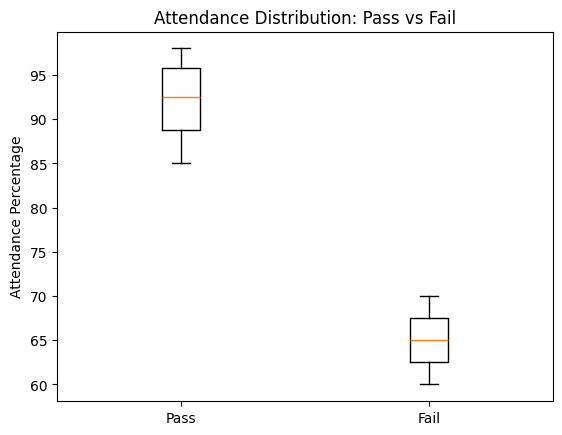

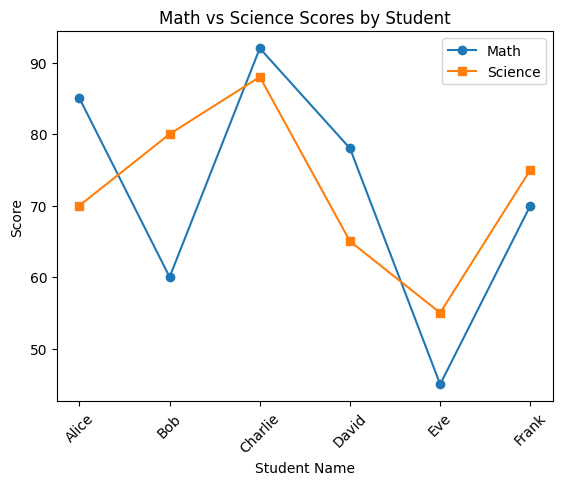

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
try:
    df = pd.read_csv("students.csv")
except FileNotFoundError:
    print("students.csv not found. Creating a dummy DataFrame for demonstration.")
    data = {
        'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
        'math': [85, 60, 92, 78, 45, 70],
        'science': [70, 80, 88, 65, 55, 75],
        'english': [90, 75, 80, 85, 60, 68],
        'history': [65, 70, 75, 90, 50, 82],
        'pe': [95, 88, 70, 75, 65, 90],
        'passed': [1, 0, 1, 1, 0, 1],
        'study_hours_per_day': [3, 1, 4, 2, 0.5, 2.5], # Added for demonstration
        'attendance_pct': [95, 70, 98, 85, 60, 90]    # Added for demonstration
    }
    df = pd.DataFrame(data)

# Create avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -------------------------------
# 1. Bar Chart — Average score per subject
# -------------------------------
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

# -------------------------------
# 2. Histogram — Math score distribution
# -------------------------------
plt.figure()
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

# -------------------------------
# 3. Scatter Plot — Study Hours vs Avg Score
# -------------------------------
plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

# -------------------------------
# 4. Box Plot — Attendance vs Pass/Fail
# -------------------------------
plt.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()

# -------------------------------
# 5. Line Plot — Math vs Science Scores
# -------------------------------
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()